# Module 1: Telco Customer Churn Prediction & Decision Modeling

Welcome to **Module 1**! In this practical lab, you will analyze customer churn for a telecommunications provider (`Telco-Customer-Churn.csv` — 7,043 customers, 21 columns).

### Business Brief:
A telecom company loses ~25% of its customers annually. Winning new customers costs 5x more than retaining existing ones. Your brief:
> *"Predict which customers are likely to churn, identify root causes, and determine the optimal intervention cutoff for retention calls."*

---

### Assignment Tasks Overview:
1. **Task 1**: Load `Telco-Customer-Churn.csv`, inspect schema, convert `TotalCharges` strings to float, and impute missing values.
2. **Task 2**: Exploratory Data Analysis — Analyze churn rates across contract types, tenure buckets, and monthly charges.
3. **Task 3**: Preprocessing & Feature Encoding — One-hot encode categorical features and scale numeric variables.
4. **Task 4**: Machine Learning Model Training — Train Logistic Regression and Random Forest classifiers.
5. **Task 5**: Business Decision Threshold Modeling — Evaluate Precision-Recall trade-offs to maximize retention campaign ROI.

In [3]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 Rows:")
print(df.head().to_string())

Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

### Task 2: Exploratory Data Analysis & Churn Drivers
Analyze how Contract Type, Tenure, and Internet Service impact churn rates.

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Impute missing TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Churn rate by Contract type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Contract Type:")
print(contract_churn["Yes"].round(2))

# Create tenure buckets
df["TenureBucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df["TenureBucket"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Rate by Tenure:")
print(tenure_churn["Yes"].round(2))

# Create MonthlyCharges buckets
df["MonthlyChargesBucket"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

charges_churn = pd.crosstab(
    df["MonthlyChargesBucket"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Rate by Monthly Charges:")
print(charges_churn["Yes"].round(2))

Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

Churn Rate by Tenure:
TenureBucket
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Yes, dtype: float64

Churn Rate by Monthly Charges:
MonthlyChargesBucket
Low          11.64
Medium       23.92
High         37.82
Very High    28.05
Name: Yes, dtype: float64



### Task 3: Model Training & Evaluation
Train a Random Forest classifier and generate a Confusion Matrix.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and prepare the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert target variable
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Remove customer ID
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Preprocessed feature shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

print("\nFirst 5 rows of processed data:")
print(X.head().to_string())

Preprocessed feature shape: (7043, 30)

Target distribution:
0    5174
1    1869
Name: Churn, dtype: int64

First 5 rows of processed data:
   SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  MultipleLines_Yes  InternetService_Fiber optic  InternetService_No  OnlineSecurity_No internet service  OnlineSecurity_Yes  OnlineBackup_No internet service  OnlineBackup_Yes  DeviceProtection_No internet service  DeviceProtection_Yes  TechSupport_No internet service  TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  StreamingMovies_No internet service  StreamingMovies_Yes  Contract_One year  Contract_Two year  PaperlessBilling_Yes  PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  PaymentMethod_Mailed check
0      -0.439916 -1.277445       -1.160323     -0.994242            0            1               0                 0                               1          

## Task 4: Machine Learning Model Training

In this task, two classification models are trained to predict customer churn:

1. **Logistic Regression** – used as a baseline classification model.
2. **Random Forest** – an ensemble model that can capture nonlinear relationships between customer features and churn.

The dataset is split into training and testing sets. Both models are evaluated using accuracy, classification reports, and confusion matrices.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric and fill missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert target to 0 and 1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Separate features and target
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)

# Evaluate Logistic Regression
print("===== LOGISTIC REGRESSION =====")
print("Accuracy:", round(accuracy_score(y_test, logistic_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

# Evaluate Random Forest
print("\n===== RANDOM FOREST =====")
print("Accuracy:", round(accuracy_score(y_test, random_forest_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, random_forest_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, random_forest_pred))

===== LOGISTIC REGRESSION =====
Accuracy: 0.8041

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Confusion Matrix:
[[925 110]
 [166 208]]

===== RANDOM FOREST =====
Accuracy: 0.7864

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409

Confusion Matrix:
[[924 111]
 [190 184]]



## Task 5: Business Decision Threshold Modeling

In this task, the predicted churn probabilities are evaluated at different classification thresholds.

The goal is to understand the trade-off between precision and recall and identify a suitable cutoff for a customer retention campaign. A lower threshold can identify more potential churners, while a higher threshold can reduce unnecessary retention calls.

The optimal threshold will be selected based on the business objective of maximizing the effectiveness of the retention campaign.

Decision Threshold Analysis:
 Threshold  Precision  Recall  F1 Score
      0.10      0.401   0.944     0.563
      0.15      0.436   0.912     0.589
      0.20      0.464   0.853     0.601
      0.25      0.503   0.802     0.619
      0.30      0.526   0.743     0.616
      0.35      0.546   0.695     0.612
      0.40      0.591   0.676     0.631
      0.45      0.617   0.626     0.622
      0.50      0.654   0.556     0.601
      0.55      0.672   0.460     0.546
      0.60      0.715   0.396     0.509
      0.65      0.753   0.310     0.439
      0.70      0.743   0.217     0.335
      0.75      0.796   0.104     0.184
      0.80      0.762   0.043     0.081
      0.85      1.000   0.003     0.005
      0.90      0.000   0.000     0.000

Recommended Decision Threshold: 0.4
Precision: 0.591
Recall: 0.676
F1 Score: 0.631



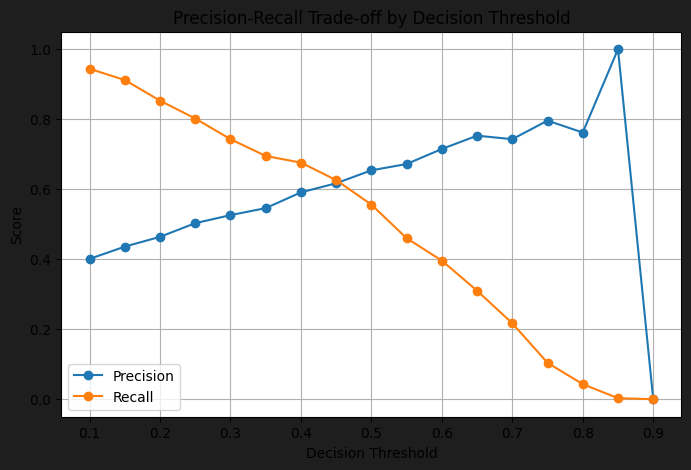

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Get churn probabilities from Logistic Regression
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Evaluate different decision thresholds
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    results.append({
        "Threshold": round(threshold, 2),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1 Score": round(f1, 3)
    })

threshold_results = pd.DataFrame(results)

print("Decision Threshold Analysis:")
print(threshold_results.to_string(index=False))

# Select threshold with the highest F1 score
best_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold = best_row["Threshold"]

print("\nRecommended Decision Threshold:", best_threshold)
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1 Score:", best_row["F1 Score"])

# Plot Precision and Recall against threshold
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()